In [1]:
import os
import numpy as np

# Use jax backend
# on macOS, this is one of the better out-of-the-box GPU options
# we have to do this first, before importing Keras ANYWHERE (including in pisces/other modules)
os.environ["KERAS_BACKEND"] = "jax"

In [2]:
from src.preprocess_and_save import do_preprocessing, big_specgram_process

LR_KERNEL_SIZE: 61


In [3]:
# do_preprocessing(big_specgram_process)

In [4]:
import numpy as np
stationary = np.load('/Users/eric/Engineering/Work/pisces/examples/NHRC/pre_processed_data/stationary/stationary_preprocessed_data_50.npy', allow_pickle=True).item()
s0 = stationary['8173033']
s0_spec = s0['spectrogram']
s0_spec.shape

(15360, 257, 3)

In [5]:
import matplotlib.pyplot as plt
def add_rgb_legend(ax):
    """
    Adds an RGB legend indicating the mapping of colors to accelerometer axes.
    """
    
    # Create a small color block with labels
    colors = ['red', 'green', 'blue']
    labels = ['X-axis (Red)', 'Y-axis (Green)', 'Z-axis (Blue)']
    for i, color in enumerate(colors):
        ax.add_patch(plt.Rectangle((0, i), 1, 1, color=color))
        ax.text(1.2, i + 0.5, labels[i], va='center', fontsize=12)

    ax.axis('off')
    ax.set_xlim(0, 2)
    ax.set_ylim(-0.5, 3)

def overlay_channels_fixed(spectrogram_tensor, mintile=5, maxtile=95, axis: plt.Axes | None = None):
    """
    Overlay spectrogram channels as an RGB image by stacking the three axes (x, y, z).
    
    Parameters:
        spectrogram_tensor (numpy.ndarray): Spectrogram tensor of shape (time_bins, freq_bins, 3).
    """
    # Normalize each channel to [0, 1] for proper RGB visualization
    norm_spec = np.zeros_like(spectrogram_tensor)
    for i in range(3):
        channel = spectrogram_tensor[:, :, i]
        p5, p95 = np.percentile(channel, [mintile, maxtile])  # Robust range
        norm_spec[:, :, i] = np.clip((channel - p5) / (p95 - p5 + 1e-8), 0, 1)  # Avoid dividing by zero
    
    # Display the combined RGB image
    if axis is None:
        axis = plt.gca()
    axis.imshow(norm_spec, aspect='auto', origin='lower')
    # add_rgb_legend(plt.gca())
    # plt.colorbar(label='Intensity')
    axis.set_xlabel('Time Bins')
    axis.set_ylabel('Frequency Bins')
    axis.set_title('Overlayed Spectrogram Channels as RGB')


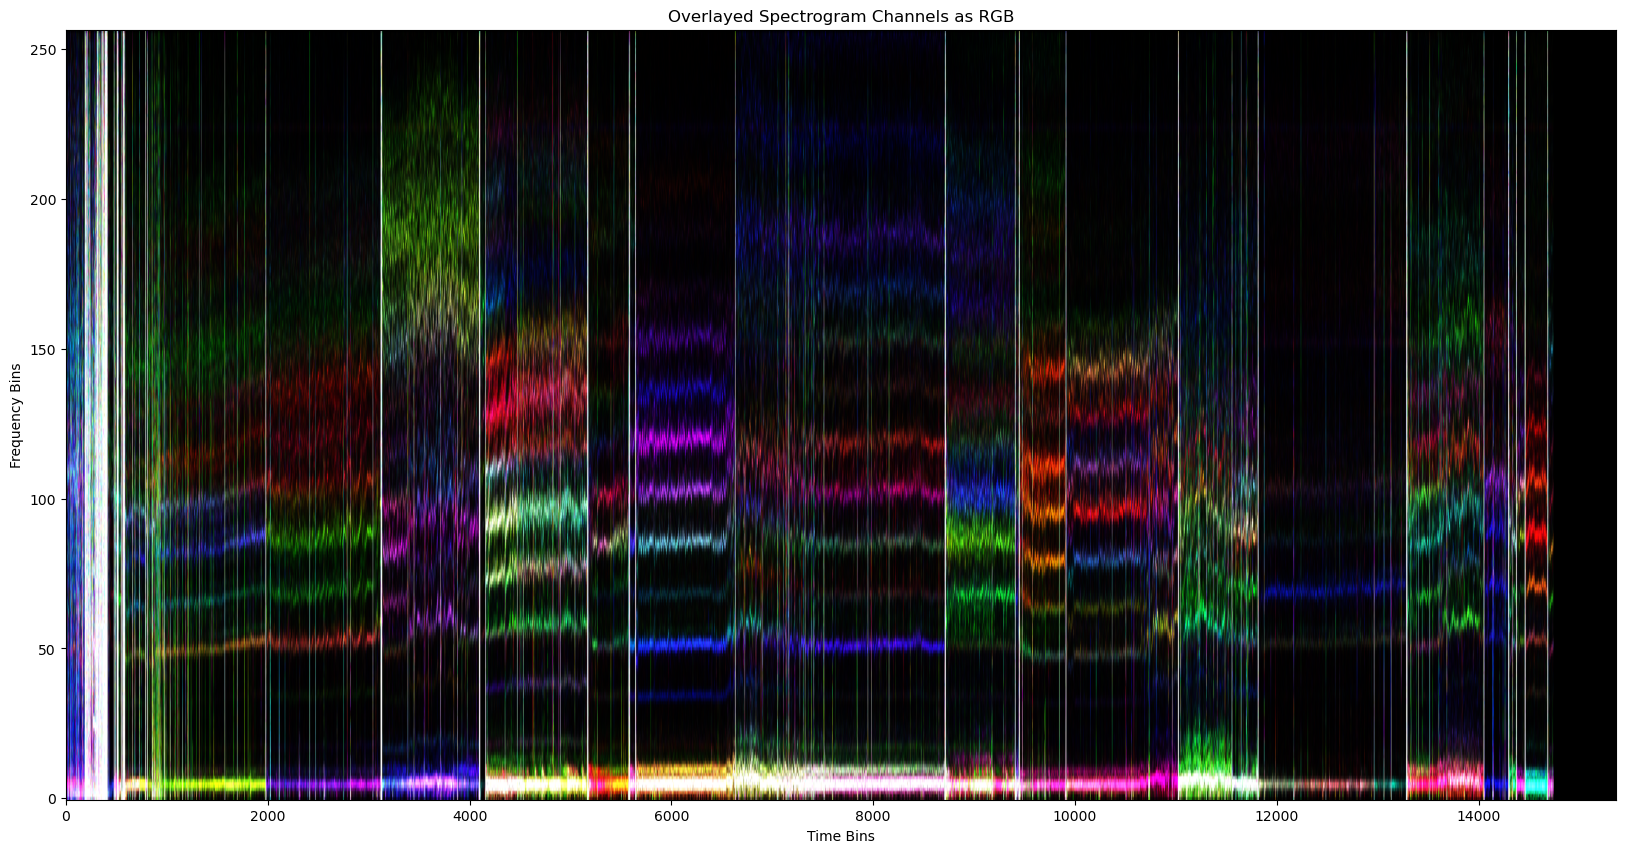

In [6]:
fig, ax = plt.subplots(1, 1, figsize=(20, 10))
overlay_channels_fixed(np.swapaxes(s0_spec, 0, 1), axis=ax)

In [7]:
def debug_normalization(spectrogram_tensor):
    for i in range(3):
        channel = spectrogram_tensor[:, :, i]
        print(f"Channel {i} - Min: {channel.min()}, Max: {channel.max()}, Mean: {channel.mean()}")

debug_normalization(s0_spec)

Channel 0 - Min: 0.0, Max: 2.2004356455616763, Mean: 0.00011417207660600776
Channel 1 - Min: 0.0, Max: 2.6464025679623195, Mean: 0.00015659879832374132
Channel 2 - Min: 0.0, Max: 3.7830375680285755, Mean: 0.00013415282057880113


In [8]:
import numpy as np
hybrid = np.load('/Users/eric/Engineering/Work/pisces/examples/NHRC/pre_processed_data/hybrid/hybrid_preprocessed_data_50.npy', allow_pickle=True).item()
h0 = hybrid['8173033']
h0_spec = h0['spectrogram']
h0_spec.shape

(15360, 257, 3)

In [9]:
debug_normalization(h0_spec)

Channel 0 - Min: 0.0, Max: 2.2468234760907215, Mean: 0.00012686104033472428
Channel 1 - Min: 0.0, Max: 2.6070787011652157, Mean: 0.0002670292145178993
Channel 2 - Min: 0.0, Max: 3.8281839227968115, Mean: 0.00018305094360102528


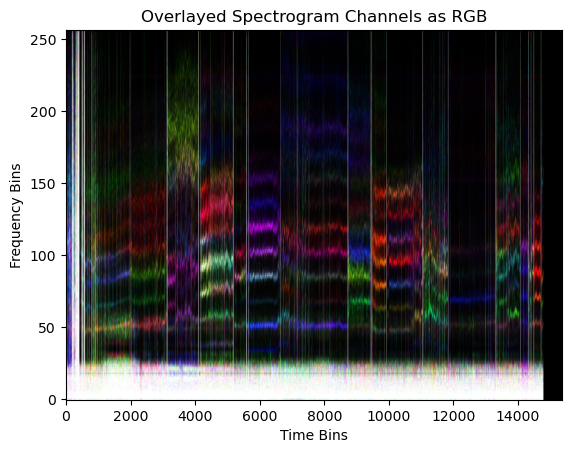

In [10]:
overlay_channels_fixed(np.swapaxes(h0_spec, 0, 1), mintile=5, maxtile=89)

# Explore the model definition
This is for the grizzly part where we repeatedly fail to call the model on our specgrams, then eventually get it right.

In [11]:
# import tensorflow as tf
from keras.layers import (
    Input, Conv2D, MaxPooling2D, UpSampling2D, Concatenate, BatchNormalization, Activation,
    AveragePooling2D, Reshape, GlobalAveragePooling2D, Lambda
)
from keras.models import Model
import jax.numpy as jnp

from examples.NHRC.nhrc_utils.new_cnn import NEW_INPUT_SHAPE

def segmentation_model(input_shape=NEW_INPUT_SHAPE, num_classes=4):
    inputs = Input(shape=input_shape)
    
    # Encoder
    c1 = Conv2D(64, (3, 3), activation='relu', padding='same')(inputs)
    c1 = BatchNormalization()(c1)
    p1 = MaxPooling2D((2, 2))(c1)  # Downsampling
    
    c2 = Conv2D(128, (3, 3), activation='relu', padding='same')(p1)
    c2 = BatchNormalization()(c2)
    p2 = MaxPooling2D((2, 2))(c2)  # Further Downsampling
    
    # c3 = Conv2D(256, (3, 3), activation='relu', padding='same')(p2)
    # c3 = BatchNormalization()(c3)
    # p3 = MaxPooling2D((2, 2))(c3)  # Bottleneck
    
    # # Decoder
    # u1 = UpSampling2D((2, 2))(p3)
    # u1 = Conv2D(128, (3, 3), activation='relu', padding='same')(u1)
    # u1 = BatchNormalization()(u1)
    # u1 = Concatenate()([u1, c3])  # Skip connection
    
    u2 = UpSampling2D((2, 2))(p2)
    u2 = Conv2D(64, (3, 3), activation='relu', padding='same')(u2)
    u2 = BatchNormalization()(u2)
    u2 = Concatenate()([u2, c2])  # Skip connection
    u2 = UpSampling2D((2, 2))(u2)
    
    # Collapse frequency axis
    collapse = AveragePooling2D(pool_size=(1, u2.shape[2]))(u2)  # Collapse frequency (128 -> 1)

    # Downsample to match label shape
    final_downsampling = AveragePooling2D(pool_size=(15, 1))(collapse)  # Downsample time (* -> 1024)
    
    # Final dense layer for class probabilities
    outputs = Conv2D(num_classes, (1, 1), activation='softmax')(final_downsampling)  # (1024, 4, 1)
    # outputs = Lambda(lambda x: tf.squeeze(x, axis=2))(outputs)  # Remove leftover spatial dimensions (1024, 4)
    outputs = Lambda(lambda x: jnp.squeeze(x, axis=2))(outputs)  # Remove leftover spatial dimensions (1024, 4)
    
    model = Model(inputs, outputs)
    return model

In [12]:
stat_spec_full_stack = np.array([
    stationary[k]['spectrogram'] for k in list(stationary.keys())
])

hybrid_spec_full_stack = np.array([
    hybrid[k]['spectrogram'] for k in list(hybrid.keys())
])

print("Stationary stack shape: ", stat_spec_full_stack.shape)
print("Hybrid stack shape: ", hybrid_spec_full_stack.shape)

Stationary stack shape:  (28, 15360, 257, 3)
Hybrid stack shape:  (28, 15360, 257, 3)


In [13]:
from nhrc_utils.analysis import stages_map
label_stack = np.array([
    stages_map(stationary[k]['psg'][:, 1]) for k in list(stationary.keys())
])


Platform 'METAL' is experimental and not all JAX functionality may be correctly supported!


Metal device set to: Apple M3 Max

systemMemory: 64.00 GB
maxCacheSize: 24.00 GB



W0000 00:00:1732287475.335744   54788 mps_client.cc:510] WARNING: JAX Apple GPU support is experimental and not all JAX functionality is correctly supported!
I0000 00:00:1732287475.336013   54788 service.cc:145] XLA service 0x3805cb150 initialized for platform METAL (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1732287475.336019   54788 service.cc:153]   StreamExecutor device (0): Metal, <undefined>
I0000 00:00:1732287475.337314   54788 mps_client.cc:406] Using Simple allocator.
I0000 00:00:1732287475.337327   54788 mps_client.cc:384] XLA backend will use up to 51539132416 bytes on device 0 for SimpleAllocator.


In [14]:
label_stack.shape

(28, 1024)